In [1]:
import pandas as pd
import os 
from glob import glob

In [2]:

# datasets = {
# "Dices": ["Gender", "Age", "Education", "Race"],
# "Epic": ["Gender", "Generation", "Nationality"],
# "MHS": ["Gender", "Age","Education", "Income", "Ideology"]
#              }

In [3]:
baseline = pd.read_csv("/home/marem/VScProjects/PersEval/predictions_lamp_llama/edited_Epic_False.csv")
baseline = baseline.rename(columns={"predictions": "baseline"})

df = baseline.copy()
list_traits = ["Gender", "Generation", "Nationality"]

for trait in list_traits:
    df_ = pd.read_csv(f"/home/marem/VScProjects/PersEval/predictions_lamp_llama/edited_Epic_{trait}_True.csv")
    new_col_name = f"model_{trait}"
    df_ = df_.rename(columns={"predictions": new_col_name})
    df_ = df_[['user_id', 'text_id', new_col_name]]
    # print(df_.columns)

    df = df.merge(df_[['user_id', 'text_id', new_col_name]], on=['user_id', 'text_id'])


In [4]:
df

,user_id,text_id,gold,baseline,model_Gender,model_Generation,model_Nationality
0,6128350698321225808,7929378450804902186,0,1,1,1,1
1,6128350698321225808,5087817458522807201,1,1,1,1,1
2,6128350698321225808,9892531563168372198,1,0,0,0,0
3,6128350698321225808,5699650005495987177,0,0,0,0,1
4,6128350698321225808,14235529860542721717,0,1,1,1,1
...,...,...,...,...,...,...,...
2539,4193747434476169473,14310872422762545117,0,0,0,0,0
2540,4193747434476169473,9866707350738211312,0,1,1,1,1
2541,4193747434476169473,15613568519546135724,0,1,0,0,0
2542,4193747434476169473,2505516355448474311,0,0,0,0,0


In [5]:
list_tasks = ['baseline', 'model_Gender', 'model_Generation', 'model_Nationality']

In [6]:
from utils.task_comparison import *

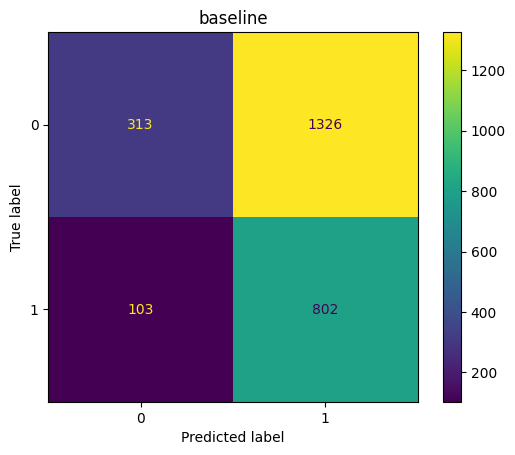

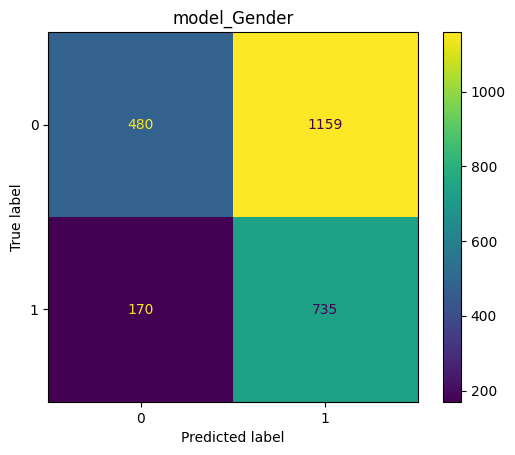

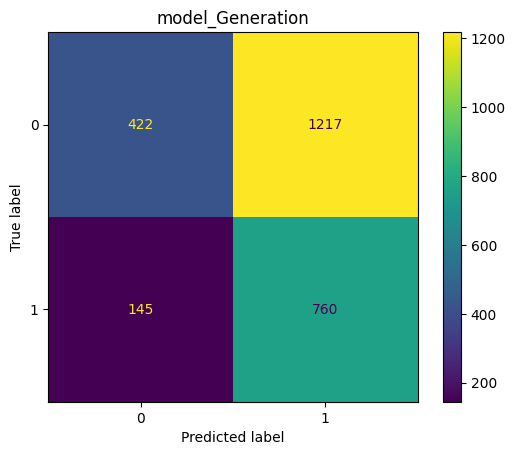

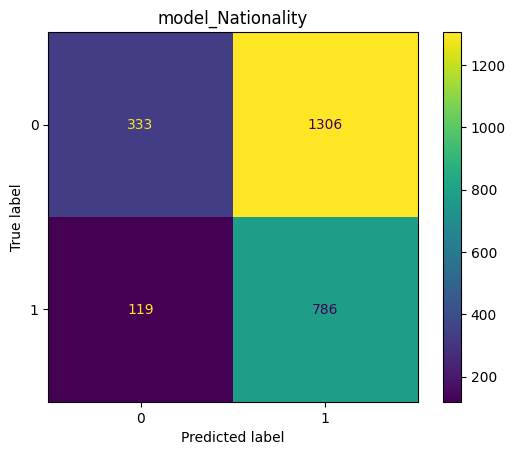

In [7]:
CM(df, list_tasks)

In [8]:
task_disagreements(df, list_tasks)

Result explanation:
# 1 = All tasks agree
# 2 = At least one task disagree 

n_unique_predictions
1    0.871069
2    0.128931
Name: proportion, dtype: float64 

baseline accuracy (on disagreements): 37.50%
model_Gender accuracy (on disagreements): 67.99%
model_Generation accuracy (on disagreements): 57.93%
model_Nationality accuracy (on disagreements): 38.72%


In [9]:
task_agreements(df, list_tasks)

Result explanation (All_agree):
# True  - All tasks gave the same label
# False - At least one task gave a different label

All_agree
True     2216
False     328
Name: count, dtype: int64



Result explanation (All_wrong):
# True  - All agreed labels are wrong (different from gold)
# False - Agreed label matches the gold label

All_wrong
True     1224
False     992
Name: count, dtype: int64 

Number of times tasks were wrong and right on each gold label
All_wrong  gold
True       0       1135
False      1        724
           0        268
True       1         89
Name: count, dtype: int64


In [10]:
def comparison_task0(df, list_tasks):
    task_cols = [task for task in list_tasks if task != "baseline"]
    print(task_cols)
    total_rows = len(df)
    comparison_percentages = {}

    for task in task_cols:
        matches = (df[task] == df["baseline"]).sum()
        comparison_percentages[task] = (matches / total_rows) * 100

    print("How many times each task give the same label as baseline: ")
    for k,v in comparison_percentages.items():
      print(k, ": ", v)

In [11]:
comp_count_ = comparison_task0(df, list_tasks)
# print(comp_count_)

['model_Gender', 'model_Generation', 'model_Nationality']
How many times each task give the same label as baseline: 
model_Gender :  89.22955974842768
model_Generation :  91.47012578616352
model_Nationality :  95.36163522012579
